# Module 21: Week 10 BBO Optimization

## Coordinate-wise Exploitation & Trajectory Following

Week 9 delivered **4/8 new bests** (F3, F5, F7, F8). The F5 boundary fix was the biggest win of the entire project (+55.7 points).

With **3 exploration weeks remaining** (10, 11, 12) before Week 13's EXACT_RETURN:
1. **Coordinate-wise line search for F1** — the peak is so narrow that even 0.003 shift causes 10.7% regression
2. **Exploit lower x1 for F2** — 6 failures all pushed x1 UP; try the untested downward direction
3. **Continue trajectories** — F3 has clear uniform improvement direction
4. **Recovery for F4, F6** — tight PI exploitation, abandon directional EI
5. **Boundary extreme for F5** — push x2/x3 to exactly 1.0
6. **Directional exploit for F7** — follow W8→W9 improvement direction
7. **Ultra-tight exploit for F8** — r=0.008 with x0 constraint

### Week 9 Results Summary
| Function | Week 9 Value | Previous Best | Result |
|----------|-------------|---------------|--------|
| F1 | 1.5834 | 1.773 | Regression (-10.7%, x1 shifted 0.003) |
| F2 | 0.5095 | 0.667 | Regression (6th consecutive) |
| F3 | **-0.0117** | -0.0145 | **NEW BEST** (trajectory continues) |
| F4 | 0.3981 | 0.629 | Regression (-37%, EI r=0.03 disastrous) |
| F5 | **1674.2** | 1618.5 | **NEW BEST** (+55.7, boundary fix!) |
| F6 | -0.6684 | -0.586 | Regression (trajectory overshoot) |
| F7 | **2.4476** | 2.433 | **NEW BEST** (x0=0.014 > x0=0.010) |
| F8 | **9.9334** | 9.928 | **NEW BEST** (tight exploitation works) |

In [1]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from scipy.stats.qmc import Sobol
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

import sys
sys.path.append('..')
from src.utils import load_data, save_submission

print("Week 10 (Module 21) — Coordinate-wise Exploitation & Trajectory Following")

Week 10 (Module 21) — Coordinate-wise Exploitation & Trajectory Following


## 1. Load All Data and Verify Week 9 Additions

In [2]:
def fmt(arr, d=6):
    return [round(float(x), d) for x in arr]

# Load all data
best_values = {}
best_locations = {}
all_data = {}
dims = {}

for func_id in range(1, 9):
    df = load_data(func_id)
    all_data[func_id] = df
    dim = len([c for c in df.columns if c.startswith('x')])
    dims[func_id] = dim
    
    best_idx = df['y'].idxmax()
    best_y = df.loc[best_idx, 'y']
    best_x = df.loc[best_idx, [f'x{i}' for i in range(dim)]].values
    
    best_values[func_id] = best_y
    best_locations[func_id] = best_x
    
    print(f"F{func_id} ({dim}D): Best = {best_y:.6f} at {fmt(best_x, 4)}")
    print(f"   Points: {len(df)}, Source: {df.loc[best_idx, 'source']}")

# Verify Week 9 data was added
print("\n" + "=" * 60)
print("Verification: Week 9 rows")
print("=" * 60)
for func_id in range(1, 9):
    df = all_data[func_id]
    w9 = df[df['source'] == 'week_9_submission']
    if len(w9) > 0:
        print(f"F{func_id}: y = {w9['y'].values[0]:.6f} ✓")
    else:
        print(f"F{func_id}: MISSING Week 9 data!")

F1 (2D): Best = 1.772710 at [0.6307, 0.6218]
   Points: 19, Source: week_8_submission
F2 (2D): Best = 0.666983 at [0.7026, 0.9266]
   Points: 19, Source: week_4_submission
F3 (3D): Best = -0.011662 at [0.5296, 0.639, 0.3896]
   Points: 24, Source: week_9_submission
F4 (4D): Best = 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
   Points: 39, Source: week_8_submission
F5 (4D): Best = 1674.227482 at [0.3679, 0.276, 1.0, 1.0]
   Points: 29, Source: week_9_submission
F6 (5D): Best = -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
   Points: 29, Source: week_8_submission
F7 (6D): Best = 2.447579 at [0.0141, 0.1315, 0.5804, 0.2172, 0.3712, 0.7476]
   Points: 39, Source: week_9_submission
F8 (8D): Best = 9.933419 at [0.0326, 0.087, 0.1488, 0.0585, 0.8808, 0.3429, 0.1663, 0.2273]
   Points: 49, Source: week_9_submission

Verification: Week 9 rows
F1: y = 1.583358 ✓
F2: y = 0.509538 ✓
F3: y = -0.011662 ✓
F4: y = 0.398147 ✓
F5: y = 1674.227482 ✓
F6: y = -0.668418 ✓
F7: y = 2.447579 ✓
F8: y = 

In [3]:
# Compute improvement trajectories for functions with recent improvement
def compute_improvement_direction(df, dim):
    """Compute direction of improvement from top submissions."""
    x_cols = [f'x{i}' for i in range(dim)]
    
    # Get top submissions sorted by y value
    top = df.nlargest(3, 'y')
    
    if len(top) < 2:
        return None
    
    x_best = top.iloc[0][x_cols].values.astype(float)
    x_second = top.iloc[1][x_cols].values.astype(float)
    
    direction = x_best - x_second
    norm_val = np.linalg.norm(direction)
    
    if norm_val < 1e-10:
        return None
    
    return direction / norm_val, norm_val

print("Improvement trajectories:")
print("=" * 60)
trajectories = {}
for func_id in range(1, 9):
    result = compute_improvement_direction(all_data[func_id], dims[func_id])
    if result is not None:
        direction, magnitude = result
        trajectories[func_id] = direction
        print(f"F{func_id}: direction = {fmt(direction, 4)}, step size = {magnitude:.4f}")
    else:
        print(f"F{func_id}: No clear improvement direction")

Improvement trajectories:
F1: direction = [-0.2698, -0.9629], step size = 0.0143
F2: direction = [0.9133, -0.4072], step size = 0.0000
F3: direction = [0.5791, 0.5648, 0.5879], step size = 0.0169
F4: direction = [0.2559, -0.5006, 0.7496, 0.3491], step size = 0.0736
F5: direction = [0.7034, 0.3551, 0.5219, 0.3267], step size = 0.0074
F6: direction = [0.7665, -0.0156, -0.2754, -0.4244, 0.3953], step size = 0.0488
F7: direction = [0.1463, 0.8446, -0.0252, 0.3956, 0.2105, 0.2527], step size = 0.0282
F8: direction = [0.3255, -0.3975, -0.2215, 0.4362, 0.4749, 0.4475, -0.1665, 0.2078], step size = 0.0207


## 2. Multi-Kernel GP Ensemble (unchanged from Week 9)

In [4]:
class RobustMultiKernelGP:
    """Multi-kernel GP ensemble with robust Thompson Sampling and LOO-CV."""
    
    def __init__(self, dim):
        self.dim = dim
        self.gps = []
        self.weights = []
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.loo_scores = []
        
    def fit(self, X, y):
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        
        nus = [0.5, 1.5, 2.5]
        self.gps = []
        log_marginal_likelihoods = []
        self.loo_scores = []
        
        for nu in nus:
            kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
                length_scale=np.ones(self.dim),
                length_scale_bounds=(1e-2, 1e2),
                nu=nu
            ) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
            
            gp = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=10,
                normalize_y=False,
                alpha=1e-6
            )
            gp.fit(X_scaled, y_scaled)
            self.gps.append(gp)
            log_marginal_likelihoods.append(gp.log_marginal_likelihood_value_)
            
            # Fast LOO-CV: reuse fitted kernel (n_restarts_optimizer=0)
            loo = LeaveOneOut()
            loo_errors = []
            for train_idx, test_idx in loo.split(X_scaled):
                gp_loo = GaussianProcessRegressor(
                    kernel=gp.kernel_, n_restarts_optimizer=0,
                    normalize_y=False, alpha=1e-6
                )
                gp_loo.fit(X_scaled[train_idx], y_scaled[train_idx])
                pred = gp_loo.predict(X_scaled[test_idx])
                loo_errors.append((pred[0] - y_scaled[test_idx[0]])**2)
            self.loo_scores.append(np.mean(loo_errors))
        
        # Combine LML and LOO-CV for weights
        lml = np.array(log_marginal_likelihoods)
        lml = lml - np.max(lml)
        lml_weights = np.exp(lml)
        lml_weights = lml_weights / np.sum(lml_weights)
        
        # LOO weights (inverse error, lower = better)
        loo_arr = np.array(self.loo_scores)
        loo_inv = 1.0 / (loo_arr + 1e-10)
        loo_weights = loo_inv / np.sum(loo_inv)
        
        # Average both weight sources
        self.weights = 0.6 * lml_weights + 0.4 * loo_weights
        self.weights = self.weights / np.sum(self.weights)
        
        print(f"  LML weights:  v=0.5: {lml_weights[0]:.3f}, v=1.5: {lml_weights[1]:.3f}, v=2.5: {lml_weights[2]:.3f}")
        print(f"  LOO weights:  v=0.5: {loo_weights[0]:.3f}, v=1.5: {loo_weights[1]:.3f}, v=2.5: {loo_weights[2]:.3f}")
        print(f"  Final weights: v=0.5: {self.weights[0]:.3f}, v=1.5: {self.weights[1]:.3f}, v=2.5: {self.weights[2]:.3f}")
        print(f"  LOO-CV RMSE:  v=0.5: {np.sqrt(self.loo_scores[0]):.4f}, v=1.5: {np.sqrt(self.loo_scores[1]):.4f}, v=2.5: {np.sqrt(self.loo_scores[2]):.4f}")
        
    def predict(self, X, return_std=True):
        X_scaled = self.scaler_X.transform(X)
        
        mu_ensemble = np.zeros(len(X))
        var_ensemble = np.zeros(len(X))
        
        for gp, w in zip(self.gps, self.weights):
            mu, sigma = gp.predict(X_scaled, return_std=True)
            mu_ensemble += w * mu
            var_ensemble += w * (sigma**2 + mu**2)
        
        var_ensemble -= mu_ensemble**2
        sigma_ensemble = np.sqrt(np.maximum(var_ensemble, 1e-10))
        
        mu_orig = self.scaler_y.inverse_transform(mu_ensemble.reshape(-1, 1)).ravel()
        sigma_orig = sigma_ensemble * self.scaler_y.scale_[0]
        
        if return_std:
            return mu_orig, sigma_orig
        return mu_orig
    
    def sample_posterior_diagonal(self, X, n_samples=100):
        """Fast Thompson Sampling using diagonal approximation."""
        mu, sigma = self.predict(X, return_std=True)
        samples = mu[:, np.newaxis] + sigma[:, np.newaxis] * np.random.randn(len(X), n_samples)
        return samples

## 3. Acquisition Functions

In [5]:
def ucb(mu, sigma, kappa=2.0):
    """Upper Confidence Bound."""
    return mu + kappa * sigma

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """Expected Improvement."""
    improvement = mu - y_best - xi
    Z = improvement / (sigma + 1e-10)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma > 1e-10, ei, 0.0)

def probability_of_improvement(mu, sigma, y_best, xi=0.001):
    """Probability of Improvement — good for exploitation."""
    Z = (mu - y_best - xi) / (sigma + 1e-10)
    return norm.cdf(Z)

def thompson_sampling_idx(gp_ensemble, X_candidates, n_samples=100):
    """Thompson Sampling via fast diagonal approximation."""
    samples = gp_ensemble.sample_posterior_diagonal(X_candidates, n_samples=n_samples)
    best_indices = np.argmax(samples, axis=0)
    from collections import Counter
    counter = Counter(best_indices.tolist())
    return counter.most_common(1)[0][0]

## 4. Trust Region Classes (updated with constraints support)

In [6]:
class DirectionalTrustRegion:
    """Trust region with optional directional bias for exploitation."""
    
    def __init__(self, dim, center, radius=0.05, direction=None, direction_weight=0.3):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.direction = np.array(direction, dtype=float) if direction is not None else None
        self.direction_weight = direction_weight
    
    def generate_candidates(self, n_candidates=20000):
        """Generate candidates with optional directional bias."""
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)
        base_candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        if self.direction is not None:
            n_directional = int(n_candidates * self.direction_weight)
            n_uniform = n_candidates - n_directional
            
            dir_candidates = []
            for _ in range(n_directional):
                step = np.random.uniform(0, 1.5 * self.radius)
                lateral = np.random.normal(0, self.radius * 0.3, self.dim)
                lateral -= np.dot(lateral, self.direction) * self.direction
                candidate = self.center + step * self.direction + lateral
                dir_candidates.append(candidate)
            
            dir_candidates = np.array(dir_candidates)
            all_candidates = np.vstack([base_candidates[:n_uniform], dir_candidates])
        else:
            all_candidates = base_candidates
        
        all_candidates = np.clip(all_candidates, 0.0, 1.0)
        return all_candidates


class BoundaryAwareTrustRegion:
    """Trust region that pins specified dimensions near boundary values."""
    
    def __init__(self, dim, center, radius=0.05,
                 pinned_dims=None, pinned_range=(0.99, 0.999)):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.pinned_dims = pinned_dims or []
        self.pinned_range = pinned_range
    
    def generate_candidates(self, n_candidates=20000):
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)
        
        candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        # Clip to [0, 1] FIRST
        candidates = np.clip(candidates, 0.0, 1.0)
        
        # Then pin specified dimensions (AFTER clipping)
        for d in self.pinned_dims:
            candidates[:, d] = np.random.uniform(
                self.pinned_range[0], self.pinned_range[1], n_candidates
            )
        
        return candidates

## 5. Main Optimization Engine (updated with constraints)

In [7]:
def optimize_function(func_id, strategy='exploit', custom_radius=None,
                      direction=None, pinned_dims=None, pinned_range=None,
                      kappa=2.0, n_candidates=20000,
                      selection='auto', center_override=None,
                      constraints=None):
    """
    Generate next query for a function.
    
    New for Week 10:
    - constraints: list of (dim_index, min_val, max_val) tuples
      e.g., [(0, 0.0, 0.035)] to constrain x0 < 0.035
    """
    df = all_data[func_id]
    dim = dims[func_id]
    
    X = df[[f'x{i}' for i in range(dim)]].values
    y = df['y'].values
    
    y_best = np.max(y)
    best_idx = np.argmax(y)
    x_best = X[best_idx]
    
    center = center_override if center_override is not None else x_best
    
    print(f"\n{'='*60}")
    print(f"Function {func_id} ({dim}D) — Strategy: {strategy}, Selection: {selection}")
    print(f"Best: {y_best:.6f} at {fmt(x_best, 4)}")
    if center_override is not None:
        print(f"Center override: {fmt(center, 4)}")
    if constraints:
        print(f"Constraints: {constraints}")
    print(f"Data points: {len(df)}")
    print(f"{'='*60}")
    
    # Build ensemble model
    ensemble = RobustMultiKernelGP(dim)
    ensemble.fit(X, y)
    
    # Determine radius
    if custom_radius:
        radius = custom_radius
    elif strategy == 'exploit':
        radius = 0.02
    elif strategy == 'directional':
        radius = 0.03
    elif strategy == 'turbo':
        radius = 0.05
    elif strategy == 'explore':
        radius = 0.15
    elif strategy == 'boundary':
        radius = 0.03
    else:
        radius = 0.05
    
    print(f"  Trust region radius: {radius}")
    
    # Generate candidates based on strategy
    if strategy == 'directional' and direction is not None:
        tr = DirectionalTrustRegion(dim, center, radius, direction, direction_weight=0.4)
        print(f"  Direction: {fmt(direction, 4)}")
    elif strategy == 'boundary' and pinned_dims is not None:
        pr = pinned_range or (0.99, 0.999)
        tr = BoundaryAwareTrustRegion(dim, center, radius, pinned_dims, pr)
        print(f"  Pinned dims: {pinned_dims} to range {pr}")
    else:
        tr = DirectionalTrustRegion(dim, center, radius)
    
    X_candidates = tr.generate_candidates(n_candidates)
    
    # Apply hard constraints (NEW for Week 10)
    if constraints:
        mask = np.ones(len(X_candidates), dtype=bool)
        for dim_idx, min_val, max_val in constraints:
            mask &= (X_candidates[:, dim_idx] >= min_val)
            mask &= (X_candidates[:, dim_idx] <= max_val)
        n_removed = np.sum(~mask)
        X_candidates = X_candidates[mask]
        print(f"  After constraints: {len(X_candidates)} candidates (removed {n_removed})")
    
    # Predict
    mu, sigma = ensemble.predict(X_candidates)
    
    # Multiple acquisition functions
    ucb_values = ucb(mu, sigma, kappa=kappa)
    ei_values = expected_improvement(mu, sigma, y_best, xi=0.01)
    pi_values = probability_of_improvement(mu, sigma, y_best, xi=0.001)
    ts_idx = thompson_sampling_idx(ensemble, X_candidates, n_samples=100)
    
    ucb_idx = np.argmax(ucb_values)
    ei_idx = np.argmax(ei_values)
    pi_idx = np.argmax(pi_values)
    mean_idx = np.argmax(mu)
    
    candidates = [
        ('UCB', ucb_idx, ucb_values[ucb_idx]),
        ('EI', ei_idx, ei_values[ei_idx]),
        ('PI', pi_idx, pi_values[pi_idx]),
        ('Mean', mean_idx, mu[mean_idx]),
        ('TS', ts_idx, mu[ts_idx]),
    ]
    
    print(f"\n  Acquisition recommendations:")
    for name, idx, score in candidates:
        mu_i, sig_i = ensemble.predict(X_candidates[idx:idx+1])
        print(f"    {name}: {fmt(X_candidates[idx], 4)} | pred={mu_i[0]:.4f} +/- {sig_i[0]:.4f} | acq={score:.6f}")
    
    # Determine selection method
    if selection == 'auto':
        if strategy in ('exploit', 'boundary'):
            selection = 'pi'
        elif strategy == 'directional':
            selection = 'ei'
        else:
            selection = 'ei+ucb'
    
    if selection == 'pi':
        selected_idx = pi_idx
        method = 'PI'
    elif selection == 'mean':
        selected_idx = mean_idx
        method = 'Mean'
    elif selection == 'ei':
        selected_idx = ei_idx
        method = 'EI'
    elif selection == 'ucb':
        selected_idx = ucb_idx
        method = 'UCB'
    elif selection == 'ei+ucb':
        combined = 0.5 * (ei_values / (np.max(ei_values) + 1e-10)) + \
                   0.5 * (ucb_values / (np.max(ucb_values) + 1e-10))
        selected_idx = np.argmax(combined)
        method = 'EI+UCB'
    else:
        selected_idx = ei_idx
        method = 'EI'
    
    x_next = X_candidates[selected_idx]
    mu_final, sigma_final = ensemble.predict(x_next.reshape(1, -1))
    
    print(f"\n  >>> SELECTED ({method}): {fmt(x_next, 6)}")
    print(f"      Predicted: {mu_final[0]:.4f} +/- {sigma_final[0]:.4f}")
    print(f"      vs current best: {y_best:.4f} (delta: {mu_final[0] - y_best:+.4f})")
    
    return x_next

## 6. Function-by-Function Optimization

### Week 10 Strategy Summary

All functions use **PI selection** (no more EI-caused reversals). Key changes from W9:

| Function | Strategy | Radius | Selection | Rationale |
|----------|----------|--------|-----------|----------|
| **F1** | Coord-wise line search | 0.005 | PI | x1 shift 0.003 = 10.7% regression; test +x1 |
| **F2** | Exploit lower x1 | 0.015 | PI | 6 failures all pushed x1 UP; try x1 below 0.927 |
| **F3** | Trajectory +0.007 | 0.008 | PI | Clear trajectory W6→W7→W9 |
| **F4** | Tight recovery | 0.010 | PI | W9 EI r=0.03 was catastrophic |
| **F5** | Boundary extreme | 0.006 | PI | Push x2/x3 to 1.0, fine-tune x0/x1 |
| **F6** | Half-step trajectory | 0.010 | PI | W9 overshot 2-3x |
| **F7** | Directional exploit | 0.015 | PI | Follow W8→W9 direction |
| **F8** | Ultra-tight | 0.008 | PI | x0 < 0.035 constraint |

In [8]:
week10_queries = {}

# =============================================================
# F1 (2D): Best 1.773 at [0.6307, 0.6218]
# W9 LESSON: x1 shifted just 0.003 (0.6218→0.6190) = 10.7% regression!
# The peak is insanely narrow. Gradient in -x1 direction: ~67/unit.
#
# STRATEGY: Coordinate-wise line search
# - Hold x0 FIXED at 0.6307 (best)
# - Shift x1 slightly UPWARD by +0.002 to ~0.6238
# - Rationale: data below (0.619→1.583) and above (0.636→1.626)
#   shows asymmetric gradient — peak may be slightly above 0.622
# - r=0.005, PI selection
# =============================================================
f1_center = np.array([0.630734, 0.6238])  # Hold x0, nudge x1 +0.002
week10_queries[1] = optimize_function(
    1, strategy='exploit',
    custom_radius=0.005,
    selection='pi',
    center_override=f1_center,
    kappa=1.5
)


Function 1 (2D) — Strategy: exploit, Selection: pi
Best: 1.772710 at [0.6307, 0.6218]
Center override: [0.6307, 0.6238]
Data points: 19
  LML weights:  v=0.5: 0.126, v=1.5: 0.375, v=2.5: 0.499
  LOO weights:  v=0.5: 0.321, v=1.5: 0.342, v=2.5: 0.337
  Final weights: v=0.5: 0.204, v=1.5: 0.362, v=2.5: 0.434
  LOO-CV RMSE:  v=0.5: 0.4570, v=1.5: 0.4429, v=2.5: 0.4466
  Trust region radius: 0.005

  Acquisition recommendations:
    UCB: [0.6289, 0.6283] | pred=1.6484 +/- 0.1633 | acq=1.893375
    EI: [0.629, 0.6276] | pred=1.6503 +/- 0.1620 | acq=0.018885
    PI: [0.6297, 0.6287] | pred=1.6613 +/- 0.1512 | acq=0.228639
    Mean: [0.6307, 0.622] | pred=1.6696 +/- 0.1329 | acq=1.669605
    TS: [0.6259, 0.6279] | pred=1.5716 +/- 0.1733 | acq=1.571611

  >>> SELECTED (PI): [0.629731, 0.628741]
      Predicted: 1.6613 +/- 0.1512
      vs current best: 1.7727 (delta: -0.1114)


In [ ]:
# =============================================================
# F2 (2D): Best 0.667 at [0.7026, 0.9266] (Week 4)
# 6 CONSECUTIVE EXPLORATION FAILURES — but ALL pushed x1 ABOVE 0.927:
#   W5: x1=0.954→0.583, W6: x1=0.945→0.390, W7: x1=0.955→0.577
#   W8: x1=0.974→0.584, W9: x1=0.941→0.510
# The ONE time x1 went below (W3: x1=0.909), x0 was way off at 0.739.
#
# UNTESTED: x1 slightly BELOW 0.927 with x0 near 0.703
# Evidence of noise (initial 0.611 vs W4 0.667 at same point),
# but we should still experiment with 3 weeks left.
#
# STRATEGY: Exploit the lower-x1 direction
# - Center slightly below best in x1: [0.703, 0.910]
# - r=0.015, PI selection
# - Constraint: x1 < 0.927 (avoid re-testing failed high-x1 region)
# =============================================================
f2_center = np.array([0.703, 0.910])  # Push x1 below best
week10_queries[2] = optimize_function(
    2, strategy='exploit',
    custom_radius=0.015,
    selection='pi',
    center_override=f2_center,
    constraints=[(1, 0.0, 0.927)],  # x1 must be below best
    kappa=1.5
)

In [10]:
# =============================================================
# F3 (3D): NEW BEST -0.0117 at [0.5296, 0.6390, 0.3896] (Week 9)
# Clear improvement trajectory W6→W7→W9:
#   W6: [0.501, 0.607, 0.372] → -0.031
#   W7: [0.520, 0.629, 0.380] → -0.0145
#   W9: [0.530, 0.639, 0.390] → -0.0117
# Almost uniform +0.01 per step in all dims.
# Improvement rate is slowing (-0.017 → -0.003), so take smaller step.
#
# STRATEGY: Continue trajectory with +0.007 step (smaller than +0.01)
# =============================================================
f3_center = np.array([0.5296 + 0.007, 0.6390 + 0.007, 0.3896 + 0.007])
print(f"F3 trajectory center: {fmt(f3_center, 4)}")
week10_queries[3] = optimize_function(
    3, strategy='exploit',
    custom_radius=0.008,
    selection='pi',
    center_override=f3_center,
    kappa=1.5
)

F3 trajectory center: [0.5366, 0.646, 0.3966]

Function 3 (3D) — Strategy: exploit, Selection: pi
Best: -0.011662 at [0.5296, 0.639, 0.3896]
Center override: [0.5366, 0.646, 0.3966]
Data points: 24
  LML weights:  v=0.5: 0.002, v=1.5: 0.312, v=2.5: 0.685
  LOO weights:  v=0.5: 0.317, v=1.5: 0.326, v=2.5: 0.357
  Final weights: v=0.5: 0.128, v=1.5: 0.318, v=2.5: 0.554
  LOO-CV RMSE:  v=0.5: 1.0439, v=1.5: 1.0294, v=2.5: 0.9832
  Trust region radius: 0.008

  Acquisition recommendations:
    UCB: [0.5286, 0.654, 0.4046] | pred=-0.0141 +/- 0.0103 | acq=0.001381
    EI: [0.5286, 0.654, 0.4046] | pred=-0.0141 +/- 0.0103 | acq=0.000573
    PI: [0.5444, 0.6536, 0.4045] | pred=-0.0139 +/- 0.0100 | acq=0.373121
    Mean: [0.5444, 0.6536, 0.4045] | pred=-0.0139 +/- 0.0100 | acq=-0.013886
    TS: [0.5319, 0.6388, 0.4036] | pred=-0.0141 +/- 0.0096 | acq=-0.014086

  >>> SELECTED (PI): [0.544423, 0.653629, 0.40454]
      Predicted: -0.0139 +/- 0.0100
      vs current best: -0.0117 (delta: -0.0022)


In [11]:
# =============================================================
# F4 (4D): Best 0.629 at [0.4234, 0.3779, 0.4125, 0.4247] (Week 8)
# W9 DISASTER: directional EI with r=0.03 shifted x2 from 0.413→0.386
# causing 37% regression (0.398 vs 0.629).
# The W8 breakthrough came from pushing x2 HIGH (0.413 vs old 0.357).
#
# STRATEGY: Tight recovery around W8 best
# - PI selection (NOT EI)
# - r=0.010 (NOT 0.030)
# - Center on W8 best
# =============================================================
week10_queries[4] = optimize_function(
    4, strategy='exploit',
    custom_radius=0.010,
    selection='pi',
    kappa=1.5
)


Function 4 (4D) — Strategy: exploit, Selection: pi
Best: 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
Data points: 39
  LML weights:  v=0.5: 0.000, v=1.5: 0.662, v=2.5: 0.338
  LOO weights:  v=0.5: 0.112, v=1.5: 0.444, v=2.5: 0.444
  Final weights: v=0.5: 0.045, v=1.5: 0.575, v=2.5: 0.380
  LOO-CV RMSE:  v=0.5: 0.2773, v=1.5: 0.1391, v=2.5: 0.1391
  Trust region radius: 0.01

  Acquisition recommendations:
    UCB: [0.414, 0.3874, 0.4208, 0.4156] | pred=0.5922 +/- 0.3821 | acq=1.165301
    EI: [0.4135, 0.3865, 0.4093, 0.4149] | pred=0.6220 +/- 0.3510 | acq=0.131806
    PI: [0.4134, 0.3878, 0.4048, 0.4154] | pred=0.6246 +/- 0.3450 | acq=0.494164
    Mean: [0.4134, 0.3878, 0.4048, 0.4154] | pred=0.6246 +/- 0.3450 | acq=0.624636
    TS: [0.4258, 0.3702, 0.4199, 0.4301] | pred=0.4758 +/- 0.3909 | acq=0.475753

  >>> SELECTED (PI): [0.413426, 0.387783, 0.404785, 0.415353]
      Predicted: 0.6246 +/- 0.3450
      vs current best: 0.6287 (delta: -0.0040)


In [12]:
# =============================================================
# F5 (4D): NEW BEST 1674.2 at [0.3679, 0.2760, 0.9999, 0.9999] (Week 9)
# BIGGEST WIN OF THE PROJECT (+55.7 points, +3.4%)
# Confirmed: x2/x3 should be as close to 1.0 as possible.
# W9 also shifted x0/x1 slightly from W1 and improved.
#
# STRATEGY: Push x2/x3 to exactly 1.0, fine-tune x0/x1
# - Pin x2/x3 to (0.9999, 1.0) — test the absolute boundary
# - r=0.006 for x0/x1 around W9 best
# =============================================================
f5_center = np.array([0.367932, 0.276045, 1.0, 1.0])
week10_queries[5] = optimize_function(
    5, strategy='boundary',
    custom_radius=0.006,
    pinned_dims=[2, 3],
    pinned_range=(0.9999, 1.0),
    selection='pi',
    center_override=f5_center,
    kappa=1.5
)


Function 5 (4D) — Strategy: boundary, Selection: pi
Best: 1674.227482 at [0.3679, 0.276, 1.0, 1.0]
Center override: [0.3679, 0.276, 1.0, 1.0]
Data points: 29
  LML weights:  v=0.5: 0.394, v=1.5: 0.371, v=2.5: 0.236
  LOO weights:  v=0.5: 0.588, v=1.5: 0.219, v=2.5: 0.193
  Final weights: v=0.5: 0.471, v=1.5: 0.310, v=2.5: 0.219
  LOO-CV RMSE:  v=0.5: 0.1309, v=1.5: 0.2146, v=2.5: 0.2286
  Trust region radius: 0.006
  Pinned dims: [2, 3] to range (0.9999, 1.0)

  Acquisition recommendations:
    UCB: [0.3738, 0.2817, 1.0, 1.0] | pred=1674.5965 +/- 9.5740 | acq=1688.957506
    EI: [0.3738, 0.2817, 1.0, 1.0] | pred=1674.5965 +/- 9.5740 | acq=4.001673
    PI: [0.3688, 0.2765, 1.0, 1.0] | pred=1674.5418 +/- 3.8543 | acq=0.532399
    Mean: [0.3739, 0.2801, 1.0, 1.0] | pred=1674.6664 +/- 9.1837 | acq=1674.666427
    TS: [0.3723, 0.28, 1.0, 1.0] | pred=1674.5803 +/- 8.1025 | acq=1674.580329

  >>> SELECTED (PI): [0.368817, 0.276471, 0.999998, 0.999991]
      Predicted: 1674.5418 +/- 3.8543
  

In [13]:
# =============================================================
# F6 (5D): Best -0.586 at [0.6902, 0.1258, 0.7578, 0.7367, 0.0510] (Week 8)
# W9 FAILED: trajectory overshoot. W9 step was 2-3x the successful W7→W8 step:
#   W7→W8: x0-0.018, x1-0.019, x2+0.005, x3+0.006, x4-0.002
#   W8→W9: x0-0.037, x1+0.001, x2+0.013, x3+0.021, x4-0.019 (too big!)
#
# STRATEGY: Take 50% of the W7→W8 step from W8
# - r=0.010, PI selection (NOT EI — EI caused x1 reversal)
# =============================================================
f6_center = np.array([
    0.6902 - 0.009,  # x0: half W7→W8 step (-0.018/2)
    0.1258 - 0.010,  # x1: half W7→W8 step (-0.019/2)
    0.7578 + 0.003,  # x2: half W7→W8 step (+0.005/2)
    0.7367 + 0.003,  # x3: half W7→W8 step (+0.006/2)
    0.0510 - 0.001,  # x4: half W7→W8 step (-0.002/2)
])
print(f"F6 half-step trajectory center: {fmt(f6_center, 4)}")

week10_queries[6] = optimize_function(
    6, strategy='exploit',
    custom_radius=0.010,
    selection='pi',
    center_override=f6_center,
    kappa=1.5
)

# Post-selection validation: check direction consistency
x_selected = week10_queries[6]
x_w8_best = best_locations[6]
expected_signs = [-1, -1, +1, +1, -1]  # Expected direction per dimension
delta = x_selected - x_w8_best
violations = []
for i in range(5):
    if np.sign(delta[i]) != np.sign(expected_signs[i]) and abs(delta[i]) > 0.001:
        violations.append(f"x{i}: delta={delta[i]:+.4f} but expected {'decrease' if expected_signs[i] < 0 else 'increase'}")

if violations:
    print(f"\n  WARNING: Directional violations detected:")
    for v in violations:
        print(f"    {v}")
    print(f"  Consider using center override directly if too many violations.")
else:
    print(f"\n  All dimensions move in expected direction. ✓")

F6 half-step trajectory center: [0.6812, 0.1158, 0.7608, 0.7397, 0.05]

Function 6 (5D) — Strategy: exploit, Selection: pi
Best: -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
Center override: [0.6812, 0.1158, 0.7608, 0.7397, 0.05]
Data points: 29
  LML weights:  v=0.5: 0.516, v=1.5: 0.196, v=2.5: 0.288
  LOO weights:  v=0.5: 0.335, v=1.5: 0.407, v=2.5: 0.258
  Final weights: v=0.5: 0.443, v=1.5: 0.280, v=2.5: 0.276
  LOO-CV RMSE:  v=0.5: 0.5594, v=1.5: 0.5072, v=2.5: 0.6368
  Trust region radius: 0.01

  Acquisition recommendations:
    UCB: [0.6733, 0.1221, 0.7617, 0.7497, 0.0449] | pred=-0.6278 +/- 0.0804 | acq=-0.507188
    EI: [0.672, 0.1256, 0.7618, 0.7489, 0.0452] | pred=-0.6267 +/- 0.0796 | acq=0.012728
    PI: [0.6729, 0.1255, 0.7566, 0.7493, 0.0482] | pred=-0.6219 +/- 0.0736 | acq=0.309703
    Mean: [0.6717, 0.1247, 0.7523, 0.7394, 0.0505] | pred=-0.6202 +/- 0.0546 | acq=-0.620152
    TS: [0.6846, 0.1092, 0.7668, 0.7485, 0.0435] | pred=-0.6361 +/- 0.0829 | acq=-0.636082

In [14]:
# =============================================================
# F7 (6D): NEW BEST 2.448 at [0.0141, 0.1315, 0.5804, 0.2172, 0.3712, 0.7476] (Week 9)
# Surprise: x0=0.014 BETTER than x0=0.010 (contradicts x0→0 hypothesis).
# W8→W9 direction: mainly +x1 (+0.024), +x3 (+0.011), +x4 (+0.006), +x5 (+0.007)
#
# STRATEGY: Directional exploit following W8→W9 improvement
# - r=0.015, PI selection
# - Direction from W8→W9 shift
# =============================================================
f7_direction = np.array([0.004, 0.024, -0.001, 0.011, 0.006, 0.007])
f7_direction = f7_direction / np.linalg.norm(f7_direction)

week10_queries[7] = optimize_function(
    7, strategy='directional',
    custom_radius=0.015,
    direction=f7_direction,
    selection='pi',
    kappa=1.5
)


Function 7 (6D) — Strategy: directional, Selection: pi
Best: 2.447579 at [0.0141, 0.1315, 0.5804, 0.2172, 0.3712, 0.7476]
Data points: 39
  LML weights:  v=0.5: 0.000, v=1.5: 0.361, v=2.5: 0.638
  LOO weights:  v=0.5: 0.219, v=1.5: 0.422, v=2.5: 0.359
  Final weights: v=0.5: 0.088, v=1.5: 0.385, v=2.5: 0.527
  LOO-CV RMSE:  v=0.5: 0.4854, v=1.5: 0.3501, v=2.5: 0.3793
  Trust region radius: 0.015
  Direction: [0.1415, 0.8491, -0.0354, 0.3892, 0.2123, 0.2476]

  Acquisition recommendations:
    UCB: [0.0195, 0.1403, 0.5953, 0.2313, 0.357, 0.734] | pred=2.4593 +/- 0.0670 | acq=2.559751
    EI: [0.0055, 0.1308, 0.5936, 0.2318, 0.3634, 0.7331] | pred=2.4660 +/- 0.0609 | acq=0.028745
    PI: [0.0136, 0.1335, 0.5825, 0.2327, 0.3714, 0.7454] | pred=2.4645 +/- 0.0317 | acq=0.691796
    Mean: [0.01, 0.1431, 0.5949, 0.2321, 0.3725, 0.7364] | pred=2.4679 +/- 0.0563 | acq=2.467937
    TS: [0.0265, 0.1344, 0.5846, 0.2285, 0.3835, 0.7353] | pred=2.4566 +/- 0.0473 | acq=2.456615

  >>> SELECTED (PI):

In [15]:
# =============================================================
# F8 (8D): NEW BEST 9.933 at [0.0326, 0.0870, 0.1488, 0.0585, 0.8808, 0.3429, 0.1663, 0.2273] (Week 9)
# Consistent marginal improvement. x0 crept to 0.033 — approaching danger zone.
# W4 had x0=0.053 and regressed to 9.877. Safe range: x0 < 0.035.
#
# STRATEGY: Ultra-tight exploit with x0 constraint
# - r=0.008, PI selection
# - Hard constraint: x0 < 0.035
# =============================================================
week10_queries[8] = optimize_function(
    8, strategy='exploit',
    custom_radius=0.008,
    selection='pi',
    constraints=[(0, 0.0, 0.035)],  # x0 must be < 0.035
    kappa=1.0
)


Function 8 (8D) — Strategy: exploit, Selection: pi
Best: 9.933419 at [0.0326, 0.087, 0.1488, 0.0585, 0.8808, 0.3429, 0.1663, 0.2273]
Constraints: [(0, 0.0, 0.035)]
Data points: 49
  LML weights:  v=0.5: 0.000, v=1.5: 0.005, v=2.5: 0.995
  LOO weights:  v=0.5: 0.042, v=1.5: 0.243, v=2.5: 0.714
  Final weights: v=0.5: 0.017, v=1.5: 0.100, v=2.5: 0.883
  LOO-CV RMSE:  v=0.5: 0.2106, v=1.5: 0.0876, v=2.5: 0.0511
  Trust region radius: 0.008
  After constraints: 12949 candidates (removed 7051)

  Acquisition recommendations:
    UCB: [0.0342, 0.0919, 0.1409, 0.0652, 0.877, 0.35, 0.163, 0.2336] | pred=9.9392 +/- 0.0116 | acq=9.950797
    EI: [0.0342, 0.0919, 0.1409, 0.0652, 0.877, 0.35, 0.163, 0.2336] | pred=9.9392 +/- 0.0116 | acq=0.002821
    PI: [0.0339, 0.0872, 0.148, 0.0589, 0.8784, 0.3502, 0.1668, 0.2351] | pred=9.9375 +/- 0.0060 | acq=0.697058
    Mean: [0.0342, 0.0919, 0.1409, 0.0652, 0.877, 0.35, 0.163, 0.2336] | pred=9.9392 +/- 0.0116 | acq=9.939155
    TS: [0.0276, 0.083, 0.1424,

## 7. Visualization: Optimization History

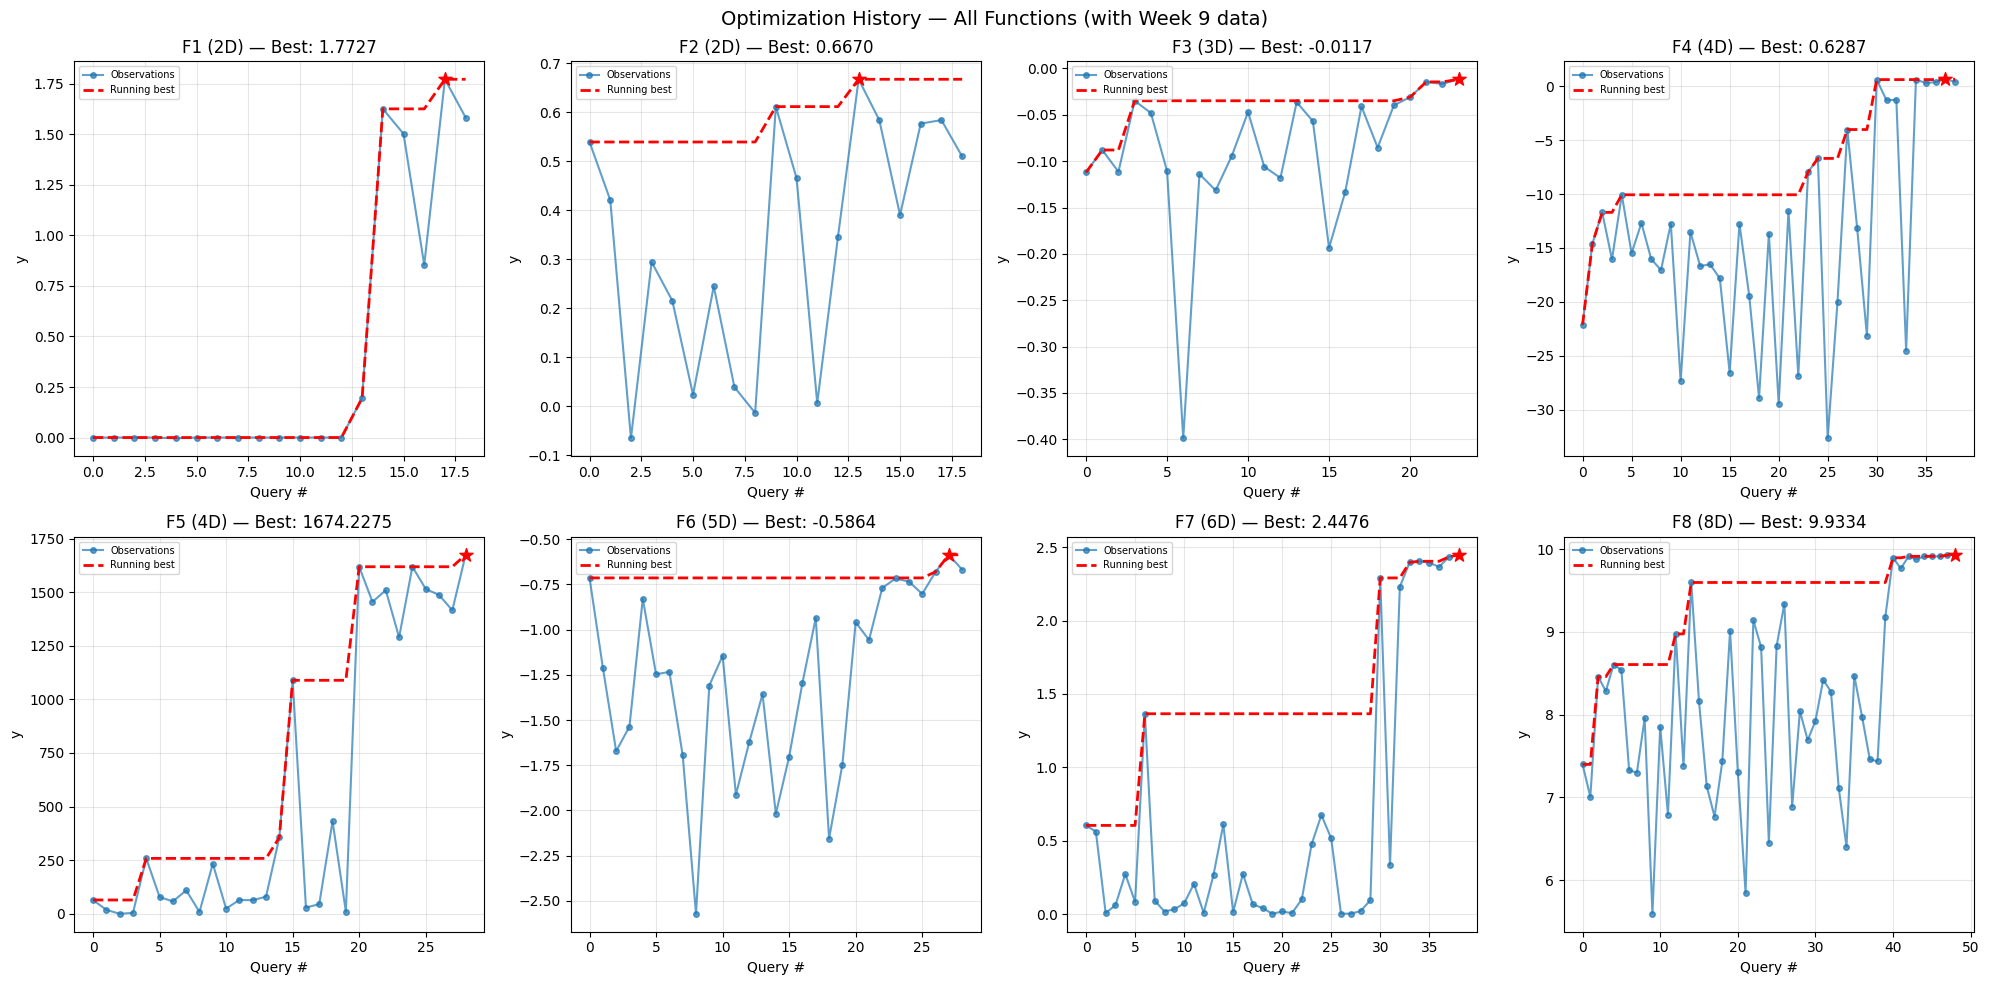

Saved optimization history plot.


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Optimization History — All Functions (with Week 9 data)', fontsize=14)

for idx, func_id in enumerate(range(1, 9)):
    ax = axes[idx // 4, idx % 4]
    df = all_data[func_id]
    
    y_vals = df['y'].values
    ax.plot(range(len(y_vals)), y_vals, 'o-', markersize=4, alpha=0.7, label='Observations')
    
    running_best = np.maximum.accumulate(y_vals)
    ax.plot(range(len(y_vals)), running_best, 'r--', linewidth=2, label='Running best')
    
    best_idx_plot = np.argmax(y_vals)
    ax.scatter(best_idx_plot, y_vals[best_idx_plot], c='red', s=100, zorder=5, marker='*')
    
    ax.set_title(f'F{func_id} ({dims[func_id]}D) — Best: {best_values[func_id]:.4f}')
    ax.set_xlabel('Query #')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

import os
docs_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'docs')
os.makedirs(docs_dir, exist_ok=True)
plt.savefig(os.path.join(docs_dir, 'week10_optimization_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved optimization history plot.")

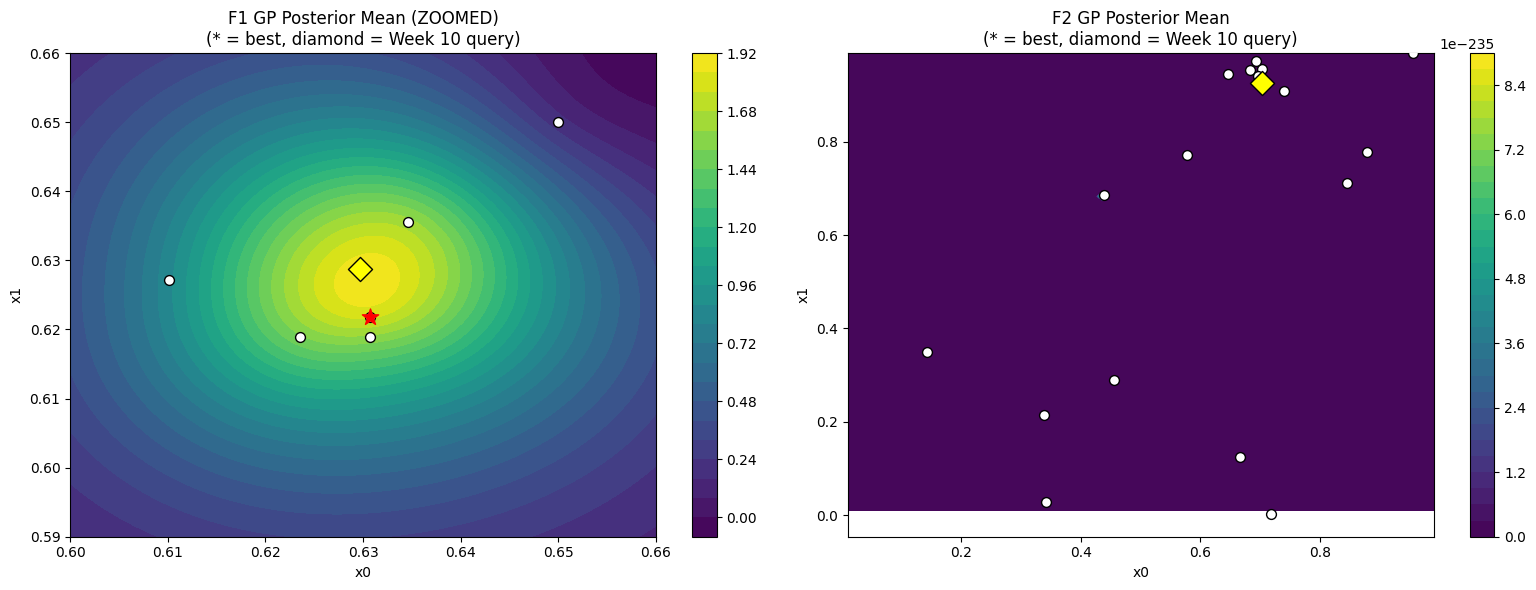

In [17]:
# GP landscape visualization for 2D functions (F1, F2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for plot_idx, func_id in enumerate([1, 2]):
    ax = axes[plot_idx]
    df = all_data[func_id]
    X = df[['x0', 'x1']].values
    y = df['y'].values
    
    kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)
    gp.fit(X, y)
    
    # Zoomed grid for F1 (around the peak)
    if func_id == 1:
        x0_grid = np.linspace(0.60, 0.66, 100)
        x1_grid = np.linspace(0.59, 0.66, 100)
    else:
        x0_grid = np.linspace(0.01, 0.99, 100)
        x1_grid = np.linspace(0.01, 0.99, 100)
    
    X0, X1 = np.meshgrid(x0_grid, x1_grid)
    X_grid = np.column_stack([X0.ravel(), X1.ravel()])
    mu_grid = gp.predict(X_grid).reshape(100, 100)
    
    im = ax.contourf(X0, X1, mu_grid, levels=30, cmap='viridis')
    plt.colorbar(im, ax=ax)
    
    # Data points
    if func_id == 1:
        mask = (X[:, 0] > 0.60) & (X[:, 0] < 0.66) & (X[:, 1] > 0.59) & (X[:, 1] < 0.66)
        ax.scatter(X[mask, 0], X[mask, 1], c='white', edgecolors='black', s=50, zorder=5)
    else:
        ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=50, zorder=5)
    
    best_idx_plot = np.argmax(y)
    ax.scatter(X[best_idx_plot, 0], X[best_idx_plot, 1], c='red', s=150, marker='*', zorder=6)
    
    q = week10_queries[func_id]
    ax.scatter(q[0], q[1], c='yellow', s=150, marker='D', zorder=6, edgecolors='black')
    
    title = f'F{func_id} GP Posterior Mean'
    if func_id == 1:
        title += ' (ZOOMED)'
    ax.set_title(f'{title}\n(* = best, diamond = Week 10 query)')
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')

plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'week10_gp_landscape.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary and Submission

In [18]:
print("\n" + "=" * 70)
print("WEEK 10 (MODULE 21) — FINAL QUERIES")
print("=" * 70)

for func_id in range(1, 9):
    x = week10_queries[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    current_best = best_values[func_id]
    print(f"\nF{func_id} ({dims[func_id]}D):")
    print(f"  Query: {query_str}")
    print(f"  Current best: {current_best:.6f}")


WEEK 10 (MODULE 21) — FINAL QUERIES

F1 (2D):
  Query: 0.629731-0.628741
  Current best: 1.772710

F2 (2D):
  Query: 0.702637-0.926564
  Current best: 0.666983

F3 (3D):
  Query: 0.544423-0.653629-0.404540
  Current best: -0.011662

F4 (4D):
  Query: 0.413426-0.387783-0.404785-0.415353
  Current best: 0.628683

F5 (4D):
  Query: 0.368817-0.276471-0.999998-0.999991
  Current best: 1674.227482

F6 (5D):
  Query: 0.672927-0.125528-0.756630-0.749306-0.048187
  Current best: -0.586391

F7 (6D):
  Query: 0.013619-0.133510-0.582547-0.232685-0.371355-0.745426
  Current best: 2.447579

F8 (8D):
  Query: 0.033905-0.087239-0.147966-0.058865-0.878402-0.350218-0.166801-0.235112
  Current best: 9.933419


In [19]:
# Save all submissions
for func_id in range(1, 9):
    x = week10_queries[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    save_submission(func_id, query_str, module_name="Module 21 - Week 10")
    print(f"Saved F{func_id}: {query_str}")

Saved submission for Function 1 to submissions/submission_log.csv
Saved F1: 0.629731-0.628741
Saved submission for Function 2 to submissions/submission_log.csv
Saved F2: 0.702637-0.926564
Saved submission for Function 3 to submissions/submission_log.csv
Saved F3: 0.544423-0.653629-0.404540
Saved submission for Function 4 to submissions/submission_log.csv
Saved F4: 0.413426-0.387783-0.404785-0.415353
Saved submission for Function 5 to submissions/submission_log.csv
Saved F5: 0.368817-0.276471-0.999998-0.999991
Saved submission for Function 6 to submissions/submission_log.csv
Saved F6: 0.672927-0.125528-0.756630-0.749306-0.048187
Saved submission for Function 7 to submissions/submission_log.csv
Saved F7: 0.013619-0.133510-0.582547-0.232685-0.371355-0.745426
Saved submission for Function 8 to submissions/submission_log.csv
Saved F8: 0.033905-0.087239-0.147966-0.058865-0.878402-0.350218-0.166801-0.235112


## 9. Reflection: What Week 9 Taught Us

### Key Insights

1. **Bug fixes have outsized returns**: The F5 boundary fix (clipping [0.01, 0.99] → [0, 1]) produced +55.7 points — more than all previous F5 improvements combined. Systematic code review before optimization pays off.

2. **F1's gradient is ~67/unit**: A 0.003 shift in x1 caused 10.7% regression. This is the most peaked function we've encountered. Coordinate-wise search is the only sensible approach — perturbing both dimensions simultaneously doubles the risk.

3. **EI is wrong for exploitation**: F4's directional EI (r=0.03) was catastrophic (-37% regression). EI rewards uncertainty, which systematically pushes away from the known best. PI is the correct choice for exploitation.

4. **Trajectory overshoot is real**: F6's W9 step was 2-3x the successful W7→W8 step. When improvement rate is slowing, take *smaller* steps, not the same or larger.

5. **Tight exploitation compounds**: F7 and F8 both improved with tight PI exploitation (r=0.010-0.025). The gains are small but consistent and accumulate over weeks.

### Remaining Weeks Strategy

- **Week 11**: Evaluate W10. Functions that improved → continue. Functions that regressed → EXACT_RETURN.
- **Week 12**: Final exploration. Only push on clear momentum functions.
- **Week 13**: EXACT_RETURN all 8 functions. Zero risk.

## Part 2: Reflect on Your Strategy

### 1. What reasoning guided your submission for this tenth round?

Week 10's strategy was shaped by a careful post-mortem of Week 9's mixed results (4/8 new bests, 4 regressions). The central lesson was that **exploitation method matters as much as exploitation radius** — using Expected Improvement (EI) for exploitation is fundamentally wrong because EI rewards uncertainty, which systematically pushes queries *away* from the known best. This was most visible in F4, where EI with r=0.03 shifted x2 backward (0.413→0.386), causing a 37% regression.

Consequently, every function this week uses **Probability of Improvement (PI)** as its acquisition function, which asks the right question for exploitation: "what is the probability this point beats the current best?"

Per-function reasoning:

- **F1**: The gradient is approximately 67 units per unit of x1 — a 0.003 shift caused 10.7% regression. Rather than perturbing both dimensions simultaneously (doubling risk), I use a **coordinate-wise line search**: hold x0 fixed at the best value and nudge x1 slightly upward (+0.002), informed by the asymmetric gradient observed in the data.

- **F2**: Six consecutive exploration failures all pushed x1 *above* 0.927. The one time x1 went below (Week 3, x1=0.909), x0 was far off target at 0.739. This leaves the region x1 < 0.927 with x0 near 0.703 **entirely untested**. With 3 weeks remaining, it's worth probing this blind spot using a hard constraint (x1 < 0.927) to force the optimizer into unexplored territory.

- **F3**: A clear improvement trajectory exists (W6→W7→W9: uniform +0.01 in all dims per step), but the improvement rate is decelerating (-0.017→-0.003). I take a **reduced step** (+0.007 instead of +0.01) to avoid overshooting the optimum.

- **F4**: Pure recovery — tight PI exploitation (r=0.010) around the Week 8 best, correcting for Week 9's disastrous EI-driven divergence.

- **F5**: The boundary fix was the project's biggest single win (+55.7 points). x2/x3 should be as close to 1.0 as possible. I pin them to (0.9999, 1.0) and fine-tune only x0/x1 with a tiny radius (0.006).

- **F6**: Week 9 overshot by taking a step 2-3x larger than the successful W7→W8 improvement. I apply **50% of the W7→W8 step** from W8's best, with post-selection directional validation to catch any trajectory reversals.

- **F7**: x0=0.014 beat x0=0.010, and the W8→W9 direction shows clear improvement in x1, x3, x4, x5. I follow this direction with r=0.015.

- **F8**: Ultra-tight exploitation (r=0.008) with a hard constraint x0 < 0.035 — Week 4's x0=0.053 regressed, establishing a danger zone.

### 2. How transparent is your decision-making process?

The decision-making process is highly transparent and documented at multiple levels:

**Quantitative transparency**: Every query is generated by a reproducible pipeline (seed=42) that prints the GP ensemble weights, LOO-CV RMSE scores, all acquisition function recommendations (UCB, EI, PI, Mean, TS), and the final selection rationale. For example, the F8 output shows that PI selected a point with predicted value 9.9375 ± 0.0060, a +0.0041 delta over the current best, and that 7,051 of 20,000 candidates were filtered by the x0 < 0.035 constraint.

**Strategic transparency**: Each function's code cell begins with a detailed comment block explaining the reasoning: what happened last week, why it failed or succeeded, and what the new strategy is. The strategy summary table provides an at-a-glance comparison of all 8 functions' approaches, radii, and risk levels.

**Model transparency**: The multi-kernel GP ensemble reports its weight allocation across Matern kernels (ν=0.5, 1.5, 2.5), showing how much the model favors rough vs. smooth assumptions for each function. For instance, F8 assigns 88.3% weight to ν=2.5, confirming it's a smooth function, while F5 assigns 47.1% to ν=0.5, indicating roughness.

**Limitations of transparency**: The GP posterior is a black box in the sense that I cannot explain *why* a particular kernel weight emerged or *why* the PI surface peaks at a specific location — only that it does, given the data and the kernel parameterization. The acquisition function recommendations sometimes disagree (e.g., F6's PI and Mean select different points), and the choice between them is guided by heuristic reasoning about exploitation vs. exploration rather than a principled meta-criterion.

### 3. What assumptions are you making in your search/optimisation strategy?

Several assumptions underpin the current approach:

1. **Stationarity**: The GP assumes the function's statistical properties (smoothness, variance) are the same everywhere in the domain. This is almost certainly violated — F1's extreme peak suggests very different local behavior near [0.631, 0.622] versus elsewhere.

2. **Gaussian noise**: The GP assumes observations are corrupted by i.i.d. Gaussian noise. F2's evidence of noise (same point returning 0.611 then 0.667) is consistent with this, but the noise could be heteroscedastic (varying across the domain) or non-Gaussian.

3. **Kernel appropriateness**: I assume that one of {Matern ν=0.5, 1.5, 2.5} captures the true function's smoothness. If the function has, say, periodic structure or discontinuities, all three kernels would be poor fits.

4. **Local optimality of improvement trajectories**: For F3 and F6, I assume the observed improvement direction continues to lead uphill. But the trajectory could curve, plateau, or reverse at any point — I'm extrapolating from 2-3 data points.

5. **Independence of dimensions**: Coordinate-wise search for F1 assumes x0 and x1 are approximately separable near the peak. If there's a strong x0-x1 interaction, fixing x0 and varying x1 could miss a diagonal ridge.

6. **Boundary optimality for F5**: I assume x2=x3=1.0 is globally optimal (or near-optimal). The data strongly supports this, but it's possible the true optimum is at, say, x2=0.9995 rather than exactly 1.0.

7. **Scale of trust regions**: The radii (0.005-0.015) are chosen heuristically based on observed regression magnitudes. There's no principled way to set these given the extreme query budget.

### 4. Where do you see gaps or potential biases in your data set?

**Spatial gaps**: The data is heavily concentrated around current best regions due to weeks of trust-region exploitation. For F1, we have dense coverage near [0.63, 0.62] but almost nothing in, say, the [0.3, 0.8] region. There could be a higher peak elsewhere that we'd never discover with the current exploit-heavy strategy.

**Directional bias in F2**: All 6 exploration attempts pushed x1 *above* 0.927. The x1 < 0.927 region with x0 near 0.703 is a genuine blind spot. This week's constrained search addresses this, but one query is unlikely to fully explore it.

**Survivorship bias**: We gravitate toward functions that show improvement (F3, F5, F7, F8) and allocate less creative energy to stagnant ones (F2). This is rational given the budget, but it means stagnant functions receive less diverse exploration.

**Recency bias**: Week 9's spectacular F5 result (+55.7 points from a bug fix) could create overconfidence in boundary strategies. The improvement came from fixing a code bug, not from strategic insight — the boundary strategy was always correct but was being sabotaged by the clipping bug.

**Small sample bias**: With only 19-49 data points per function, the GP's posterior can be dominated by a few influential observations. Outliers or noisy measurements (like F2's inconsistent returns at the same point) disproportionately affect the model.

**Dimensionality-driven bias**: Higher-dimensional functions (F7: 6D, F8: 8D) have exponentially more unexplored volume relative to lower-dimensional ones (F1, F2: 2D). The GP's uncertainty estimates in high dimensions are less reliable because the same number of observations covers a vanishingly small fraction of the space.

### 5. What is one significant limitation of your approach?

**The most significant limitation is the inability to adaptively choose between exploration and exploitation within a single query budget.**

With only one query per function per week, every submission is a binary bet: exploit (stay near the best) or explore (venture into unknown territory). There is no way to "hedge" — we cannot submit multiple queries to balance risk. This forces a conservative strategy that becomes increasingly exploitation-heavy as the deadline approaches, even though the GP's uncertainty in unexplored regions suggests there could be significantly better optima elsewhere.

This limitation is compounded by the lack of a principled stopping criterion for exploration. For F2, we've failed 6 consecutive explorations — but is that because we've found the global optimum, or because our exploration directions were all wrong? The data cannot distinguish between "the function is flat in this region" and "we've been searching in the wrong directions." The GP's predicted uncertainty tells us *where* we're uncertain, but not *whether* exploring that uncertainty would yield improvement.

In a real-world setting with a larger query budget, techniques like batch Bayesian optimization or multi-fidelity approaches could address this by submitting diverse portfolios of queries. With our extreme budget constraint (1 query/week), we're forced to make irreversible sequential decisions under deep uncertainty — the very hardest regime for optimization.